## Import Library

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from scipy.stats import wilcoxon

## Load Dataset

In [39]:
df = pd.read_csv('../Data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')
print(f'Dataset awal shape: {df.shape}')
df.head()

Dataset awal shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## Preprocessing

### 1. Drop kolom 

In [40]:
# Metadata
metadata_cols = [
    "FILENAME",
    "URL",
    "Domain",
    "Title"
]

# Fitur yang berpotensi leakage
dominans_cols = [
    "URLSimilarityIndex",
    "URLTitleMatchScore",
    "DomainTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb"
]

content_features = [
    "LineOfCode", "LargestLineLength", "HasTitle", "HasFavicon", "Robots", 
    "IsResponsive", "NoOfURLRedirect", "NoOfSelfRedirect", "HasDescription", 
    "NoOfPopup", "NoOfiFrame", "HasExternalFormSubmit", "HasSocialNet", 
    "HasSubmitButton", "HasHiddenFields", "HasPasswordField", "Bank", "Pay", 
    "Crypto", "HasCopyrightInfo", "NoOfImage", "NoOfCSS", "NoOfJS", 
    "NoOfSelfRef", "NoOfEmptyRef", "NoOfExternalRef"
]

drop_cols = metadata_cols + dominans_cols + content_features
existing_cols = [col for col in drop_cols if col in df.columns]
df_model = df.drop(columns=existing_cols)

### 2. Features dan Target

In [41]:
X = df_model.drop(columns=["label"])
y = (df_model["label"] == 0).astype(int)

print(f"Features shape setelah drop content features: {X.shape} | Target shape: {y.shape}")
print(f"Target shape: {y.shape}")
print("\nTarget distribution:")
print(y.value_counts(normalize=True).rename({0: "Legitimate", 1: "Phishing"}))

Features shape setelah drop content features: (235795, 20) | Target shape: (235795,)
Target shape: (235795,)

Target distribution:
label
Legitimate    0.571895
Phishing      0.428105
Name: proportion, dtype: float64


### 3. Training Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (188636, 20)
X_test : (47159, 20)
y_train distribution:
label
0    0.571895
1    0.428105
Name: proportion, dtype: float64
y_test distribution:
label
0    0.571895
1    0.428105
Name: proportion, dtype: float64


### 4. Encode & Filter

In [43]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """
    Mengubah fitur kategorikal menjadi representasi frekuensi berbasis data training.
    Dioptimalkan untuk menghemat penggunaan RAM.
    """
    def __init__(self, cols=None):
        self.cols = cols or []
        self.maps_ = {}

    def fit(self, X, y=None):
        # Hindari penyalinan seluruh dataframe, cukup hitung map dari kolom yang dituju
        for col in self.cols:
            if col in X.columns:
                self.maps_[col] = X[col].value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        # Lakukan transformasi langsung (inplace=False secara default pada .map)
        X_out = X.copy()
        for col, mapping in self.maps_.items():
            if col in X_out.columns:
                X_out[col] = X_out[col].map(mapping).fillna(0).astype(np.float32)
        return X_out

class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Menghapus fitur dengan korelasi tinggi (>0.90) untuk mencegah redundansi
    sesuai dengan metodologi pada jurnal referensi.
    """
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.keep_cols_ = None

    def fit(self, X, y=None):
        # Konversi ke DataFrame jika input berupa numpy array
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        # Hitung matriks korelasi secara efisien
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        
        # Tentukan fitur yang akan dipertahankan
        self.keep_cols_ = [col for col in X_df.columns if not any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        return X_df[self.keep_cols_]

### 5. Cross Validation Setup

In [44]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

## Modeling

### 1. Definisi Model & Fungsi Evaluasi

In [45]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_split=50,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        max_depth=14,
        min_samples_split=20,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=1 
    )
}

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    k_best = 15 if X_train.shape[1] > 15 else 'all'

    pipe = Pipeline([
        ("freq_encoder", FrequencyEncoder(cols=["TLD"] if "TLD" in X_train.columns else [])),
        ("corr_filter", CorrelationFilter(threshold=0.90)),
        ("anova", SelectKBest(score_func=f_classif, k=k_best)), # <-- k_best dimasukkan ke sini
        ("classifier", model)
    ])

    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False, 
        n_jobs=2 
    )

    pipe.fit(X_train, y_train)

    y_pred_test = pipe.predict(X_test)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "CV Precision": cv_result["test_precision"].mean(),
        "CV Recall": cv_result["test_recall"].mean(),
        "CV F1-Score": cv_result["test_f1"].mean(),
        "CV ROC AUC": cv_result["test_roc_auc"].mean(),
        "CV PR AUC": cv_result["test_pr_auc"].mean(),

        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Test Precision": precision_score(y_test, y_pred_test, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred_test, zero_division=0),
        "Test F1-Score": f1_score(y_test, y_pred_test, zero_division=0),
        "Test ROC AUC": roc_auc_score(y_test, y_proba_test),
        "Test PR AUC": average_precision_score(y_test, y_proba_test)
    }

    return metrics, y_pred_test, y_proba_test, pipe, cv_result

### 2. Training & Evaluasi Semua Model

In [46]:
results = []
predictions = {}
trained_pipelines = {}
cv_raw_scores = {}

for name, model in models.items():
    print(f"Training {name}...")

    metrics, y_pred, y_proba, pipe, cv_result = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test,
        name
    )

    results.append(metrics)
    predictions[name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }
    trained_pipelines[name] = pipe
    cv_raw_scores[name] = cv_result

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
results_df = results_df.sort_values("Test ROC AUC", ascending=False)
results_df

Training Decision Tree...
Training Random Forest...


,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC AUC,CV PR AUC,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC AUC,Test PR AUC
Model,,,,,,,,,,,,
Random Forest,0.996204,0.997452,0.993672,0.995558,0.998777,0.998985,0.996438,0.997515,0.994155,0.995832,0.998804,0.999049
Decision Tree,0.995202,0.996914,0.991864,0.994382,0.997562,0.997820,0.995335,0.997162,0.991926,0.994537,0.997806,0.998013


### 4. Visualisasi Perbandingan Model

C:\Users\deoim\AppData\Local\Temp\ipykernel_32644\642158032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\deoim\AppData\Local\Temp\ipykernel_32644\642158032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\deoim\AppData\Local\Temp\ipykernel_32644\642158032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\deoim\AppData\Local\Temp\ipykernel_32644\642158032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

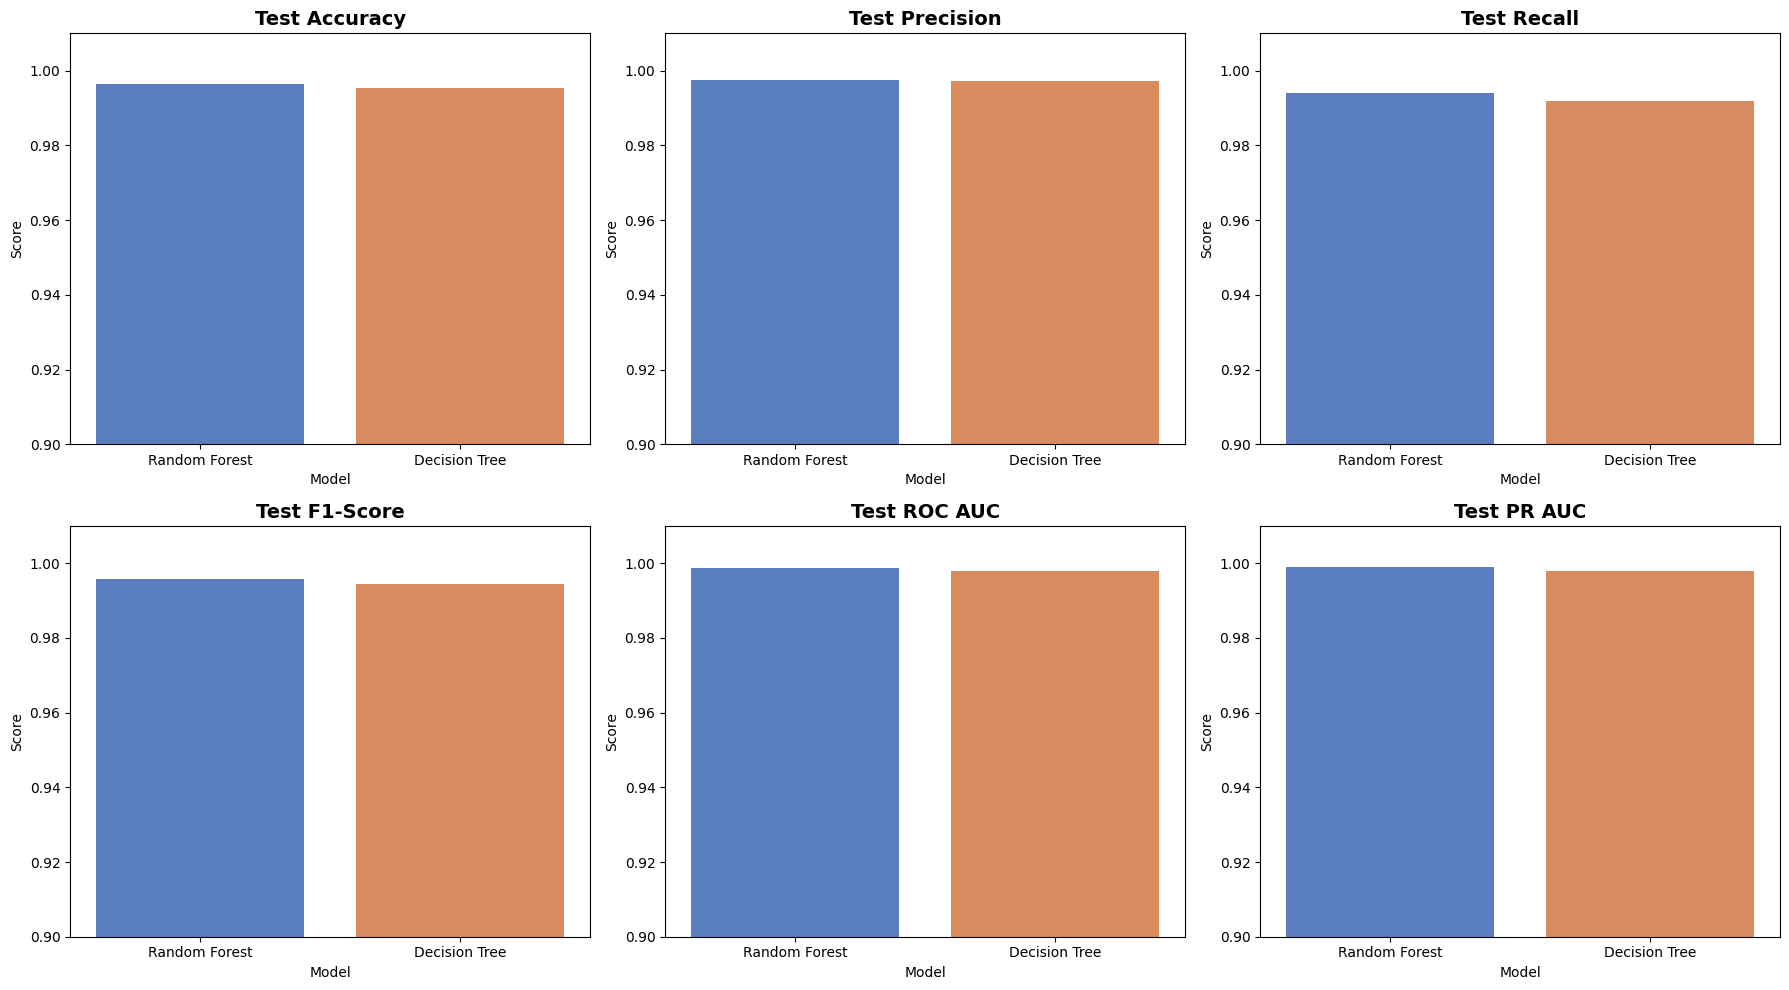

In [47]:
metrics_to_plot = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Test ROC AUC", "Test PR AUC"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(
        data=results_df.reset_index(),
        x="Model",
        y=metric,
        ax=axes[i],
        palette="muted"
    )
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.90, 1.01)
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

### 5. ROC Curve

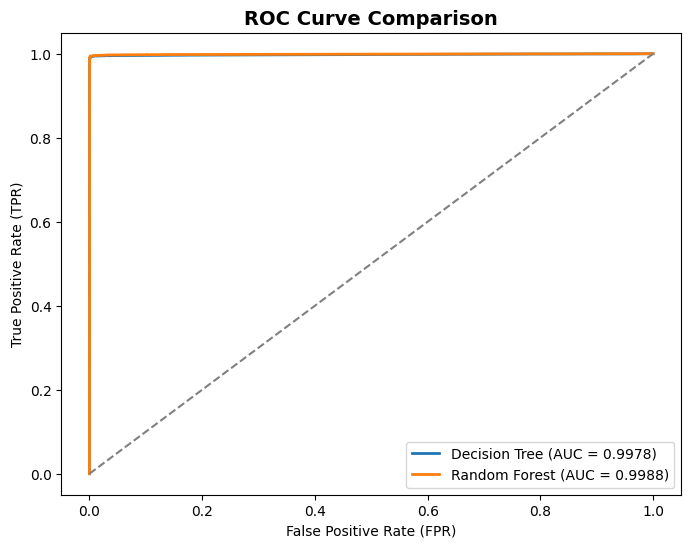

In [48]:
plt.figure(figsize=(8, 6))

for model_name, pred in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred["y_proba"])
    auc_score = results_df.loc[model_name, "Test ROC AUC"]
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color='grey')
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve Comparison", fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

#### 6. Confusion Matrix untuk Model Terbaik

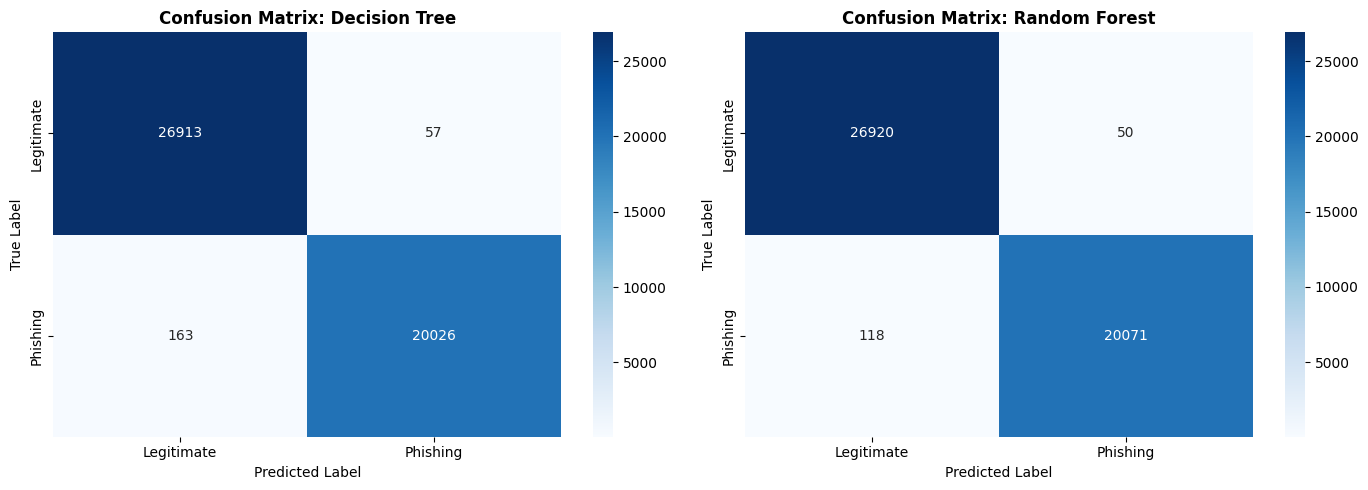

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (model_name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=["Legitimate", "Phishing"], 
                yticklabels=["Legitimate", "Phishing"])
    axes[idx].set_title(f"Confusion Matrix: {model_name}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Feature Importance

Best Model: Random Forest


C:\Users\deoim\AppData\Local\Temp\ipykernel_32644\2420297910.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


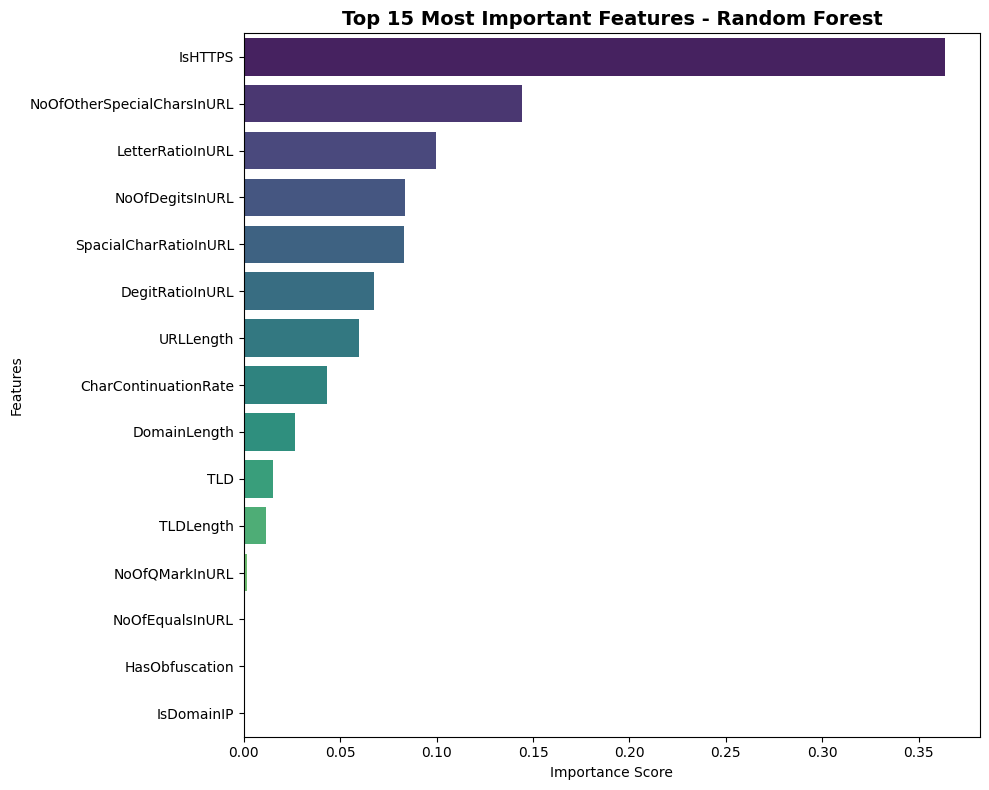

In [50]:
best_model_name = results_df.index[0]
print(f"Best Model: {best_model_name}")

best_pipe = trained_pipelines[best_model_name]

corr_features = best_pipe.named_steps["corr_filter"].keep_cols_

# Ekstrak masking True/False dari tahap ANOVA (SelectKBest)
anova_support = best_pipe.named_steps["anova"].get_support()

selected_features = np.array(corr_features)[anova_support]
classifier = best_pipe.named_steps["classifier"]
importances = classifier.feature_importances_

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)
top_features = importance_df.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    palette="viridis" 
)

plt.title(f"Top 15 Most Important Features - {best_model_name}", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()